In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("household_power_consumption.txt", sep=';', low_memory=False)

In [3]:
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

df = df[['Datetime', 'Global_active_power']]
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

df = df.dropna()
df = df.set_index('Datetime')

C:\Users\Mubarik Amin\AppData\Local\Temp\ipykernel_6120\4029935909.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])


In [4]:
df = df.resample('H').mean()
df = df.dropna()

C:\Users\Mubarik Amin\AppData\Local\Temp\ipykernel_6120\64728432.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.resample('H').mean()


In [5]:
df['hour'] = df.index.hour
df['weekday'] = df.index.weekday
df['is_weekend'] = (df['weekday'] >= 5).astype(int)

In [6]:
train_size = int(len(df) * 0.8)

train = df[:train_size]
test = df[train_size:]

y_train = train['Global_active_power']
y_test = test['Global_active_power']

In [7]:
from statsmodels.tsa.arima.model import ARIMA

arima = ARIMA(y_train, order=(2,1,2))
arima_fit = arima.fit()

arima_pred = arima_fit.forecast(len(y_test))

C:\Users\Mubarik Amin\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Mubarik Amin\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Mubarik Amin\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Mubarik Amin\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros a

In [9]:
pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.1 MB 2.9 MB/s eta 0:00:04
   ----- ---------------------------------- 1.6/12.1 MB 3.7 MB/s eta 0:00:03
   -------- ------------------------------- 2.6/12.1 MB 4.1 MB/s eta 0:00:03
   ------------ --------------------------- 3.7/12.1 MB 4.3 MB/s eta 0:00:02
   ---------------- ----------------------- 5.0/12.1 MB 4.5 MB/s eta 0:00:02
   ------------------- -------------------- 5.8/12.1 MB 4.6 MB/s eta 0:00:02
   ----------------------- ---------------- 7.1/12.1 MB 4.6 MB/s eta 0:00:02
   ------------------------ --------------- 7.3/12.1 MB 4.7 MB/s eta 0:00:02
   ------------------------ --------------- 7.3/12.1 MB 4.7 MB/s eta 0:00:02
   ------------------------- -------------- 7.9/12.1 MB 3.7 MB/s eta 0:00:02
   -----------------

In [10]:
from prophet import Prophet

prophet_df = df.reset_index()[['Datetime', 'Global_active_power']]
prophet_df.columns = ['ds', 'y']

train_p = prophet_df[:train_size]
test_p = prophet_df[train_size:]

model = Prophet()
model.fit(train_p)

future = model.make_future_dataframe(periods=len(test_p), freq='H')
forecast = model.predict(future)

prophet_pred = forecast['yhat'][-len(test_p):].values


12:16:20 - cmdstanpy - INFO - Chain [1] start processing
12:16:26 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\Mubarik Amin\AppData\Local\anaconda3\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


In [12]:
pip install xgboost


   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.7 MB/s eta 0:00:58
    --------------------------------------- 1.6/101.7 MB 3.3 MB/s eta 0:00:31
   - -------------------------------------- 3.1/101.7 MB 4.5 MB/s eta 0:00:22
   - -------------------------------------- 4.5/101.7 MB 4.9 MB/s eta 0:00:20
   -- ------------------------------------- 5.8/101.7 MB 5.2 MB/s eta 0:00:19
   -- ------------------------------------- 6.3/101.7 MB 5.3 MB/s eta 0:00:18
   -- ------------------------------------- 6.3/101.7 MB 5.3 MB/s eta 0:00:18
   -- ------------------------------------- 7.1/101.7 MB 4.1 MB/s eta 0:00:24
   -- ------------------------------------- 7.3/101.7 MB 3.9 MB/s eta 0:00:25
   --- -------

In [13]:
from xgboost import XGBRegressor

features = ['hour', 'weekday', 'is_weekend']

X_train = train[features]
X_test = test[features]

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(name, y_true, y_pred):
    print("\n", name)
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

evaluate("ARIMA", y_test, arima_pred)
evaluate("Prophet", y_test, prophet_pred)
evaluate("XGBoost", y_test, xgb_pred)


 ARIMA
MAE: 0.8113783029770656
RMSE: 0.9349425851217777

 Prophet
MAE: 0.6548822504699044
RMSE: 0.8210154144203023

 XGBoost
MAE: 0.49865986533176543
RMSE: 0.6668943171853708


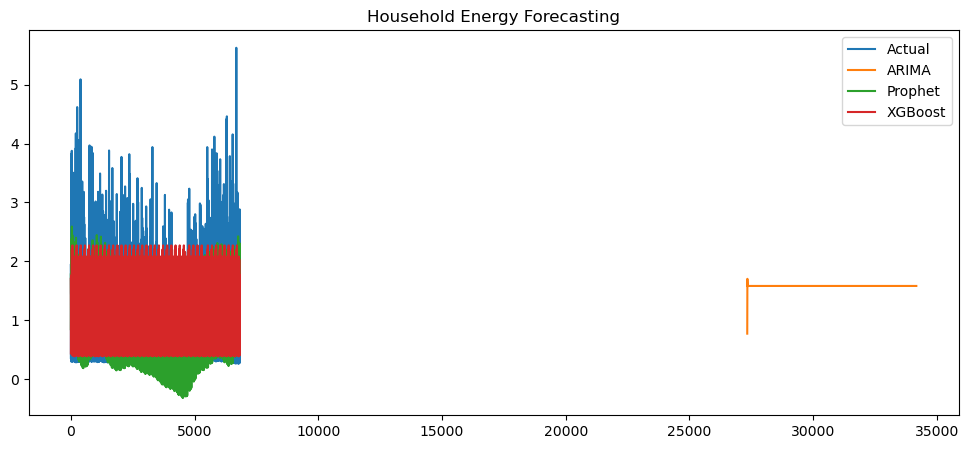

In [15]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values, label="Actual")
plt.plot(arima_pred, label="ARIMA")
plt.plot(prophet_pred, label="Prophet")
plt.plot(xgb_pred, label="XGBoost")

plt.legend()
plt.title("Household Energy Forecasting")
plt.show()